**index for w_t...** : index of three previous words, in ~17000 word vocab, the index is 17000-1

**C** : lookup-table, which is the word embedding layer of size vocab * ~30 or any other (not so) arbitrary number, so for the 17000 words of size 30 = (17000, 30)

C is a lookup-table basically, because every word index is picking one row from the table, and each word is converted into a vector (1, 30) (word embedding) which corresponds to the row in the table

the input layer is 30 (30, 30) neurons for the 3 words, and table C is the same for each word

the hidden layer is a hyperparameter, i.e. it's defineable and up to the designer of the network to define. hidden layer is fully connected layer with tnah non-linearity

Output layer is the size of the vocab, so (17000, 30), which is fully connected to the hidden layer. there are 17000 logits in the output layer, and it has a softmax layer to that we have a probability distribution for the next word in the sequence.

in training we have the next word, and with that we maximize the probability of the word with respect to the parameters of the network.

The parameters are the weights and biases of all the layers (output, hidden and the lookup-table). all of them are optimized using back propagation.

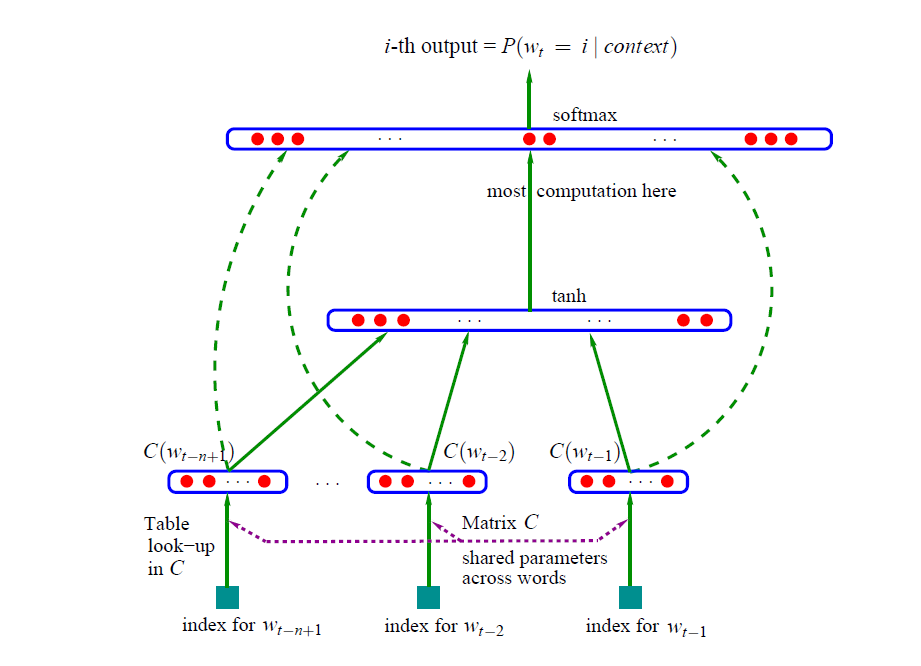

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [2]:
words = open('names.txt', 'r').read().splitlines()
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [4]:
len(words)

32033

In [3]:
chars = sorted(list(set(''.join(words))))
stoi = {c: i+1 for i, c in enumerate(chars)}
stoi['.'] = 0
itos = {i: c for c, i in stoi.items()}

In [ ]:
# build the dataset with block 3 size context window

block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []

for w in words[:5]:
    print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

In [55]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

In [58]:
C = torch.rand(27, 2) # each 27 characters will have a 2-dim embedding

In [60]:
# creating the embedding layer
# one way is to just index into the C-tables row, C[ix], e.g. :
C[5]

tensor([0.1612, 0.2978])

In [66]:
# one is using one-hot -encoding
F.one_hot(torch.tensor(5), num_classes=27).float() @ C

# and as you can see, one-hot -encoding picks the same row as straight indexing
# in this case indexing is faster, so discard one-hot -encoding

tensor([0.1612, 0.2978])

In [72]:
# different ways of indexing into tensors
C[0:3]
C[[0,1,2]]
C[torch.tensor([0,1,2])]

tensor([[0.8990, 0.1935],
        [0.0828, 0.0284],
        [0.6120, 0.7479]])

In [79]:
C[X].shape # the original X (32,3) encoded into 2-dim embedding -> (32, 3, 2)

torch.Size([32, 3, 2])

In [93]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [97]:
# initialize the hidden layer
# input will be 3*2 = 6 (from embedding layer (32, 3, 2)), three characters embedded into 2-dim matrices
# hidden size will be 100 neurons

W1 = torch.randn((6, 100))
b1 = torch.randn(100)

In [ ]:
# hidden layer takes 6 inputs, 3 2-dim embedded characters, but right now the emb layer is
# (32, 3, 2). we need to change the shape of the emb layer to match the input of the hidden layer.
# use torch.concat for this:

x = torch.randn(2, 3)
print(x)
print(x.shape)

print(torch.cat((x,x,x), 0).shape) # concat by row-axis
print(torch.cat((x,x,x), 1).shape) # concat by col-axis

# dim indexing is same in pandas, np, torch, etc. such that dim equals (0,1,2,..,n), or dim -1 = last dim

tensor([[-0.4900,  2.1080, -0.5890],
        [ 0.4763,  1.4899,  1.0977]])
torch.Size([2, 3])
torch.Size([6, 3])
torch.Size([2, 9])


In [112]:
# so to concat the embedding layer:
torch.cat((emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]), 1).shape

# but the problem is hard-coding index_slicing which is not viable when the code is changed
# e.g. for params tuning

torch.Size([32, 6])

In [ ]:
# use torch.unbind to remove a dimension

print(emb.shape)
torch.cat(torch.unbind(emb, 1), 1).shape

# BUT!! torch.cat creates copies of tensors and takes up memory and creates all sorts of problems

torch.Size([32, 3, 2])


torch.Size([32, 6])

In [ ]:
# there's still a better way to change the dimension of tensors:

a = torch.arange(18)
print(a.shape)
a

torch.Size([18])


tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17])

In [132]:
# change the shape of the tensor with .view(), which is extremely efficient

a.view(2, 9)

tensor([[ 0,  1,  2,  3,  4,  5,  6,  7,  8],
        [ 9, 10, 11, 12, 13, 14, 15, 16, 17]])

In [ ]:
emb.view(32, 6) == torch.cat((emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]), 1)
emb.view(32, 6) == torch.cat(torch.unbind(emb, 1), 1)

In [ ]:
# so now trying to do a matrix multiplication on the hidden layer does not return an error:

try:
    emb @ W1 + b1
except Exception:
    print("first operation emb @ W1 + b1 failed, matrices don't match")

hid = emb.view(-1, 6) @ W1 + b1 # use -1 here so pythorch infers it from other dimensions
print(hid)
print(hid.shape)

first operation emb @ W1 + b1 failed, matrices don't match
tensor([[ 3.5014, -1.8522,  0.5170,  ..., -1.8049, -1.3731,  3.9926],
        [ 2.1365, -1.2055,  2.3310,  ..., -0.7371, -0.7725,  3.5306],
        [ 3.8623, -2.7703, -0.6566,  ..., -1.7794, -0.6736,  4.7327],
        ...,
        [ 3.8071, -2.5880, -0.1519,  ..., -1.7660,  0.2013,  5.0218],
        [ 4.3705, -2.5773, -0.2408,  ..., -1.8078, -0.2312,  4.5282],
        [ 2.0086, -1.5317,  3.0075,  ..., -0.4441, -0.6507,  3.2085]])
torch.Size([32, 100])


In [ ]:
# CONTINUE --->
# hidden layer has tanh non-linearity:

h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
h.shape

# here the broadcasting attribute needs to be taken into account (well not for this, since it does
# what it's supposed to), since elementwise addition is broadcasted by adding a dimension to the b1
# matrix (b1 = (100) => (1, 100)):
# 32, 100
# 100       this goes to:
# 32, 100
#  1, 100   because of broadcasting, and adds the bias term to all the rows of (32, 100)

torch.Size([32, 100])

In [149]:
h.shape

torch.Size([32, 100])

In [ ]:
# try to understand the broadcasting logic

a = torch.ones(5, 2)
bias = torch.rand(2)

a + bias

bias = torch.randn(4)
torch.randn((2, 3)) @ torch.randn((3, 4)) + bias

tensor([[ 0.3232, -1.7233, -0.0179, -0.8022],
        [ 0.6032, -0.7442, -0.6027, -0.0979]])

In [195]:
# build the second (and last) layer

W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [196]:
logits = h @ W2 + b2
logits = logits.exp()
probs = logits / logits.sum(1, keepdim=True)

In [203]:
# to index into the probabilities of the neural nets, take labels Y and index into the probabilities matrix

probs[torch.arange(32), Y]

tensor([3.6515e-04, 1.0442e-02, 1.7493e-01, 2.4922e-06, 2.4446e-12, 9.5600e-07,
        1.1938e-02, 4.5025e-08, 2.8559e-05, 3.5891e-11, 1.2709e-05, 2.0441e-10,
        7.4984e-05, 3.6142e-04, 4.8548e-05, 3.5823e-12, 5.5861e-09, 1.8147e-08,
        2.2165e-04, 1.0949e-07, 8.2089e-02, 1.1878e-06, 1.9722e-06, 1.8329e-05,
        1.5817e-13, 2.2862e-08, 1.9899e-06, 4.1529e-07, 6.6924e-01, 3.6258e-08,
        5.3895e-06, 2.0874e-11])

In [218]:
# for example, take index 5 from Y and the element in the position = 15
print(Y)
print(Y[5])
probs[0, 15]

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])
tensor(15)


tensor(9.5600e-07)

In [209]:
probs[0, 15]

tensor(9.5600e-07)

In [221]:
# negative log likelihood loss:

loss = -probs[torch.arange(32), Y].log().mean()
loss

tensor(13.7962)

In [222]:
# ------------CLEARLY WRITTEN-----------#

In [27]:
# create the dataset with all the words

# build the dataset with block 3 size context window

block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []

for w in words:
    #print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        #print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

In [7]:
X.shape, Y.shape # the datasets

(torch.Size([228146, 3]), torch.Size([228146]))

In [59]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.rand(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [60]:
sum(p.nelement() for p in parameters) # total number of parameters

3481

In [ ]:
# since we're not reinventing the wheel, just pick cross entropy loss from torch
# using lib functions is much more efficient, since pytorch does not create the intermediate
# matrices for the calculations and reserve memory, also backwards pass is much more efficient

'''
This is how the forward pass was calculated, with the nll implemented with intermediate steps
emb = C[X] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2

# loss ->
counts = logits.exp()
probs = counts / counts.sum(1, keepdim=True)
loss = -probs[torch.arange(32), Y].log().mean()
# <- loss

loss
'''

In [ ]:
# iterating for the learning rate
# generate learningrates between 0.001 and 1
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [62]:
# initialize parameter grads
for p in parameters:
    p.requires_grad = True

In [74]:
#lri = []
#lossi = []

for i in range(10000):
    
    #mini-batch construct
    ix = torch.randint(0, X.shape[0], (32,))
    
    # forward pass
    emb = C[X[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    # loss
    loss = F.cross_entropy(logits, Y[ix])

    # backwards pass
    for p in parameters:
        p.grad=None
    loss.backward()

    # update
    lr = 0.001 # lrs[i]
    for p in parameters:
        p.data += -lr * p.grad
    
    # track states
    #lri.append(lre[i])
    #lossi.append(loss.item())



In [75]:
# check the loss for the whole dataset

emb = C[X] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
# loss
loss = F.cross_entropy(logits, Y)
loss

tensor(2.3446, grad_fn=<NllLossBackward0>)

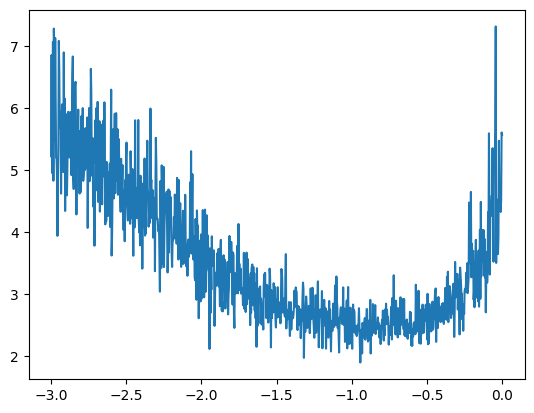

[(tensor(-0.9429), 1.8948144912719727),
 (tensor(-1.3183), 1.9698381423950195),
 (tensor(-0.8739), 2.0404019355773926),
 (tensor(-0.9309), 2.0409018993377686),
 (tensor(-1.0841), 2.0554778575897217)]

In [57]:
# plot the losses against the learning rates
plt.plot(lri, lossi)
plt.show()
pairs = [(lr, loss) for lr, loss in zip(lri, lossi)]
sorted(pairs, key=lambda x: x[1])[:5]

In [52]:
pairs = [(lr, loss) for lr, loss in zip(lri, lossi)]

In [55]:
sorted(pairs, key=lambda x: x[1])[:5]

[(tensor(-0.9429), 1.8948144912719727),
 (tensor(-1.3183), 1.9698381423950195),
 (tensor(-0.8739), 2.0404019355773926),
 (tensor(-0.9309), 2.0409018993377686),
 (tensor(-1.0841), 2.0554778575897217)]

In [ ]:
# about mini-batching
'''
In mini-batch training, each gradient is a noisy approximation of the full-dataset gradient. 
Although each individual step is less precise, mini-batches let us compute updates much more 
cheaply and frequently, and in practice this often leads to faster and better training than 
using the exact full gradient at every step. Under random sampling, mini-batch gradients 
approximate the full-dataset gradient on average, even though the exact optimization path and 
final parameters may differ. More broadly, even the full dataset itself is only a finite 
sample from the underlying real-world data distribution, not the totality of all possible cases.
'''

In [ ]:
# about learning-rate decay
'''
When optimizing the gradients, we can start with a larger lr value and decay once we start to
plateau, e.g. 0.1->0.01->0.001. The reason being that once you start getting closer to the minima, 
with larger lryou essentially jump from one edge to the opposite, and inching the lr a little lower 
will help fine-tune the model. I started decaying at ~2.45 and anded up at ~2.35, which is already
higher than the previous bigram model.
'''

In [76]:
# splitting the dataset into training split, dev/validation split and test split.
# train split is for training the mode, dev split is for traingin the hyperparameters,
# and the test split is to evaluate the model
# 80%, 10%, 10%
# next let's split the dataset into train/dev/test sets

In [79]:
# build the datasets
def build_dataset(words):
    block_size = 3
    X, Y = [], []

    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [103]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.rand(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [104]:
for p in parameters:
    p.requires_grad = True

In [113]:
#lri = []
#lossi = []

# run the training split

for i in range(10000):
    
    #mini-batch construct
    ix = torch.randint(0, Xtr.shape[0], (32,))
    
    # forward pass
    emb = C[Xtr[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    # loss
    loss = F.cross_entropy(logits, Ytr[ix])

    # backwards pass
    for p in parameters:
        p.grad=None
    loss.backward()

    # update
    lr = 0.01 # lrs[i]
    for p in parameters:
        p.data += -lr * p.grad
    
    # track states
    #lri.append(lre[i])
    #lossi.append(loss.item())



In [116]:
loss.item()

2.3048877716064453

In [ ]:
# check the loss for the dev dataset

emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
# loss
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.3049, grad_fn=<NllLossBackward0>)

In [117]:
# compare to the loss of training split

emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
# loss
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.3056, grad_fn=<NllLossBackward0>)

In [ ]:
'''
training and dev split losses are similar and not very good. this implies underfitting.
since this is a small model, we could benefit of adding more parameters to the model.
when model is underfitting, it might be:
- the model is too small
- the context window is too small
- it has not trained long enough
- the optimization is not strong enough
- the features or architecture are too limited

overfitting would be that the model learns the training set too well but wont generalize
to the dev set.
'''

In [123]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 300), generator=g)
b1 = torch.rand(300, generator=g)
W2 = torch.randn((300, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

print('num params: ', sum([p.nelement() for p in parameters]))

num params:  10281


In [124]:
for p in parameters:
    p.requires_grad = True

In [137]:
lri = []
lossi = []
stepi = []

# run the training split

for i in range(30000):
    
    #mini-batch construct
    ix = torch.randint(0, Xtr.shape[0], (32,))
    
    # forward pass
    emb = C[Xtr[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    # loss
    loss = F.cross_entropy(logits, Ytr[ix])

    # backwards pass
    for p in parameters:
        p.grad=None
    loss.backward()

    # update
    lr = 0.01 # lrs[i]
    for p in parameters:
        p.data += -lr * p.grad
    
    # track states
    #lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.item())



In [ ]:
plt.plot(stepi, lossi)

In [139]:
# check the loss for the dev dataset

emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
# loss
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.2327, grad_fn=<NllLossBackward0>)

In [138]:
# compare to the loss of training split

emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
# loss
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.2246, grad_fn=<NllLossBackward0>)

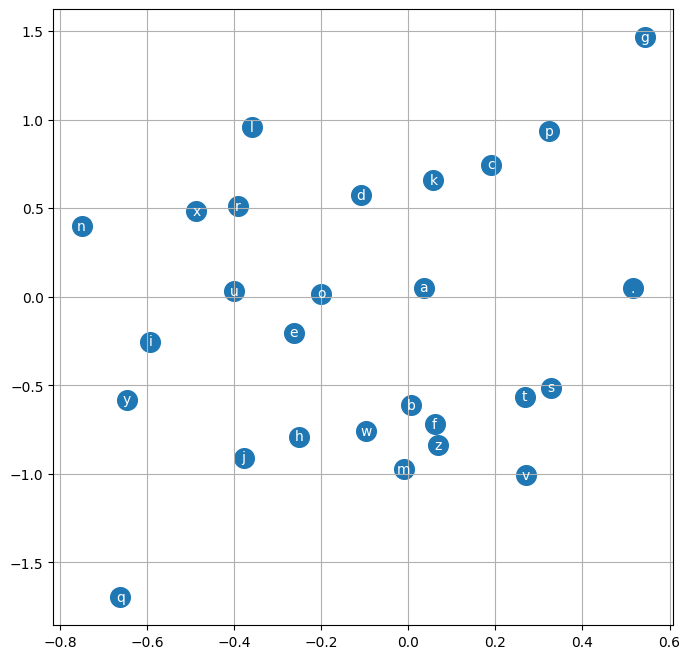

In [ ]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha='center', va='center', color='white')
plt.grid('minor')

'''
the model has learned something, since the vowels seem to be clustered in the center and
outlier characters li q and . are on the edges. So the embedding vectors are somewhat similar.
'''

In [142]:
# add more neurons to the model

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.rand(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

print('num params: ', sum([p.nelement() for p in parameters]))

num params:  11897


In [143]:
for p in parameters:
    p.requires_grad = True

In [144]:
# initialize tracking states here
lri = []
lossi = []
stepi = []

In [154]:
# run the training split

for i in range(50000):
    
    #mini-batch construct
    ix = torch.randint(0, Xtr.shape[0], (32,))
    
    # forward pass
    emb = C[Xtr[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
    logits = h @ W2 + b2
    # loss
    loss = F.cross_entropy(logits, Ytr[ix])

    # backwards pass
    for p in parameters:
        p.grad=None
    loss.backward()

    # update
    lr = 0.01 # lrs[i]
    for p in parameters:
        p.data += -lr * p.grad
    
    # track states
    #lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())



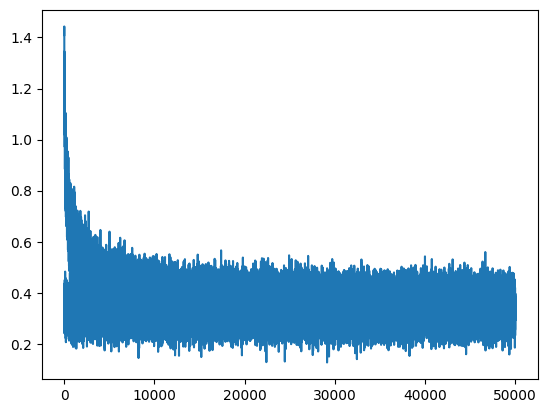

In [155]:
plt.plot(stepi, lossi)

In [156]:
emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
# loss
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1565, grad_fn=<NllLossBackward0>)

In [157]:
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
# loss
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1802, grad_fn=<NllLossBackward0>)